## Exercice 2: le challenge pour scrapper des données 

Extraire les données d'état civil de la commune d'**Abbécourt (Aisne)** depuis le site `archives.aisne.fr`
et livrer un fichier CSV/Excel structuré contenant :
la commune, le type d'acte, les années couvertes, la cote du registre, et un lien direct vers l'image.

Le sujet précise que la page peut présenter des **obstacles techniques volontaires**, et que ce qui est évalué
c'est **comment on diagnostique un blocage, quels outils on utilise, et comment on le contourne**.


In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://archives.aisne.fr/archive/resultats/etatcivil/n:11/limit:50?RECH_commune_Index=1%7C&RECH_commune_Libel=Abb%C3%A9court+%28Aisne%29%7C&type=etatcivil&communes_TabSel=1&RECH_Field=RECH_commune&RECH_Letter=A&RECH_annee_debut=1860"
response = requests.get(url)
print(response.status_code)   
print(len(response.content))  

403
94


> 🔴 **Signal d'alerte immédiat :** Le code HTTP est 403 (erreur) on ne peut pas acceder au lien

Solution:  Le User-Agent est un en-tête HTTP envoyé avec chaque requête. Il permet au serveur d'identifier le type de client (navigateur, application, script Python, etc.) et certains sites adaptent leur réponse ou appliquent des règles de filtrage en fonction de cette information.

Le test a montré que le comportement du serveur variait selon le User-Agent utilisé, ce qui indique que celui-ci faisait partie des critères pris en compte pour accepter ou refuser la requête.

In [12]:
import requests

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/137.0.0.0 Safari/537.36"
    )
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.text)

200
<!doctype html><html lang="en"><head><title>Making sure you&#39;re not a bot!</title><link rel="stylesheet" href="/.within.website/x/xess/xess.min.css?cachebuster=1.24.0-38-g4e0df8c-dev"><meta name="viewport" content="width=device-width, initial-scale=1.0"><meta name="robots" content="noindex,nofollow"><style>
        body,
        html {
            height: 100%;
            display: flex;
            justify-content: center;
            align-items: center;
            margin-left: auto;
            margin-right: auto;
        }

        .centered-div {
            text-align: center;
        }

        #status {
            font-variant-numeric: tabular-nums;
        }

        #progress {
            display: none;
            width: 90%;
            width: min(20rem, 90%);
            height: 2rem;
            border-radius: 1rem;
            overflow: hidden;
            margin: 1rem 0 2rem;
            outline-offset: 2px;
            outline: #b16286 solid 4px;
        }

 

In [9]:
pip install requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**Réflexe :** sauvegarder le HTML brut pour l'inspecter :

In [13]:
with open("debug_page.html", "wb") as f:
    f.write(response.content)

## Étape 2 — Obstacle #1 : Découverte de la protection anti-bot Anubis

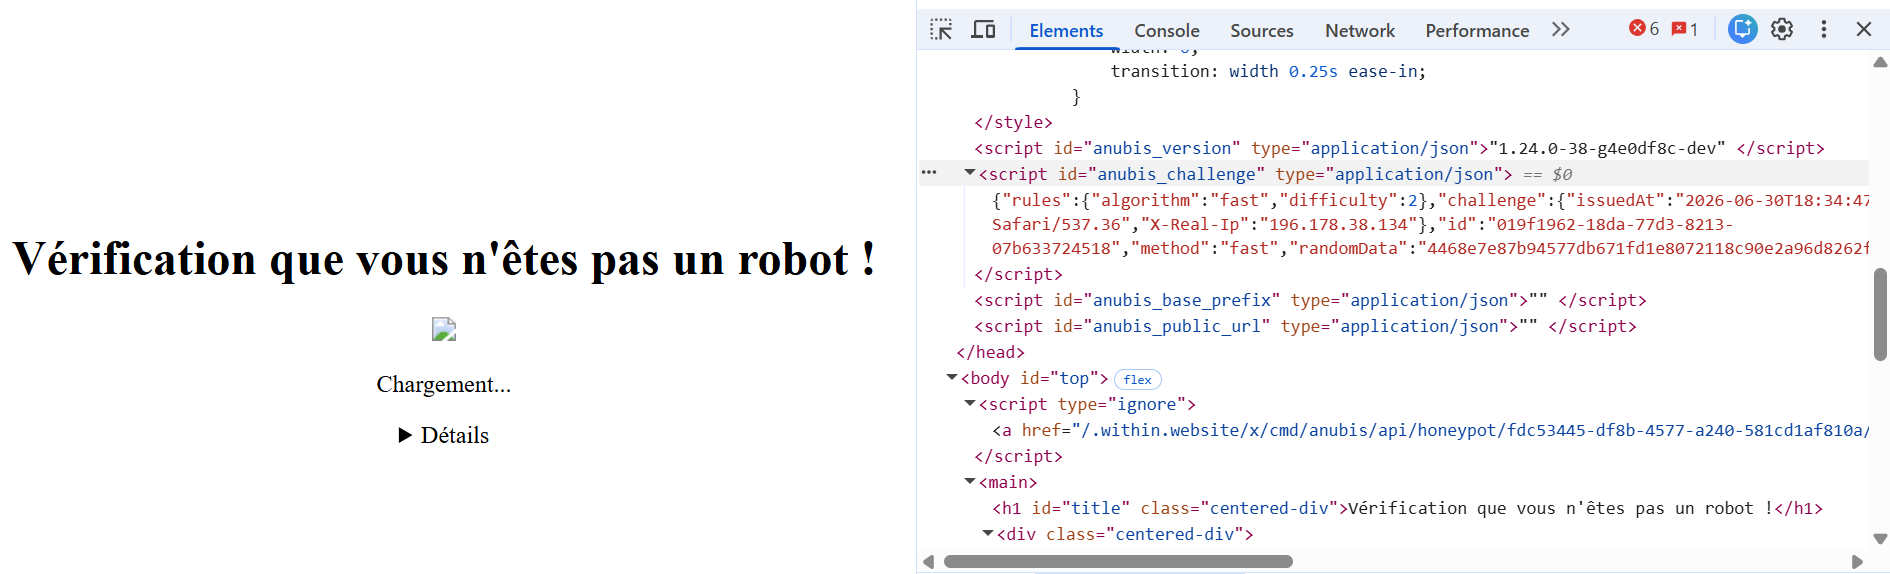

**T+5 min · Diagnostic**

En ouvrant `debug_page.html` dans le navigateur :

> *« Vérification que vous n'êtes pas un robot ! »*

Et dans le code source HTML, une balise révélatrice :

```html
<script id="anubis_challenge" type="application/json">
{
  "rules": { "algorithm": "fast", "difficulty": 2 },
  "challenge": {
    "id":         "019f195e-a4b2-...",
    "randomData": "4468e7e87b94577db671...",   ← 128 caractères hex
    "difficulty": 2
  }
}
</script>
<script src="/.within.website/.../anubis_main.mjs"></script>
```

**Ce qui se passe :** Le serveur répond 200 OK mais envoie une **page de challenge JavaScript** à la place
des vraies données. Un navigateur exécute ce JS automatiquement. `requests` ne l'exécute pas —
il reçoit juste le HTML vide.

C'est le middleware **Anubis** (open-source, github.com/TecharoHQ/anubis), conçu pour bloquer
les scrapers et bots automatisés.

In [15]:
requests.get(url, headers=headers)

<Response [200]>

### Diagnostic de la protection anti-bot

En inspectant le code source de la page à l'aide des outils de développement du navigateur (**F12**), j'ai identifié plusieurs éléments caractéristiques de la protection **Anubis**, notamment :

- une balise `<script id="anubis_challenge" type="application/json">` contenant les informations du challenge ;
- un module JavaScript `main.mjs`, chargé d'exécuter la logique de vérification avant d'autoriser l'accès à la page réelle.

Cette analyse m'a permis de comprendre que les données n'étaient pas directement accessibles par une simple requête HTTP et qu'une étape de validation côté navigateur était nécessaire avant d'obtenir le contenu des registres.

### Accéder au donnée du site: Explication de la fonction `solve_anubis_pow()` (`extract_all_pages.py`)

Cette fonction permet de résoudre automatiquement le challenge de sécurité mis en place par **Anubis** avant d'accéder aux données du site.

Concrètement, le serveur demande au client de résoudre un petit défi avant d'autoriser l'accès à la page. La fonction commence par lire les informations de ce défi dans le code HTML, puis elle essaie automatiquement plusieurs valeurs (`0`, `1`, `2`, `3`, ...).

À chaque essai, elle effectue un calcul appelé **SHA-256**, qui produit une sorte d'**empreinte numérique** unique à partir des données utilisées. La fonction répète ce calcul jusqu'à obtenir un résultat qui respecte la condition imposée par le serveur.

Une fois la bonne réponse trouvée, elle l'envoie au serveur. Si celui-ci la valide, il considère que le challenge a été réussi et autorise l'accès aux données.

> **En résumé :** cette fonction essaie automatiquement plusieurs valeurs jusqu'à trouver la bonne réponse au défi demandé par le serveur, ce qui permet ensuite d'accéder à la page contenant les registres.

### Obstacle n°2 : Structure HTML non conventionnelle

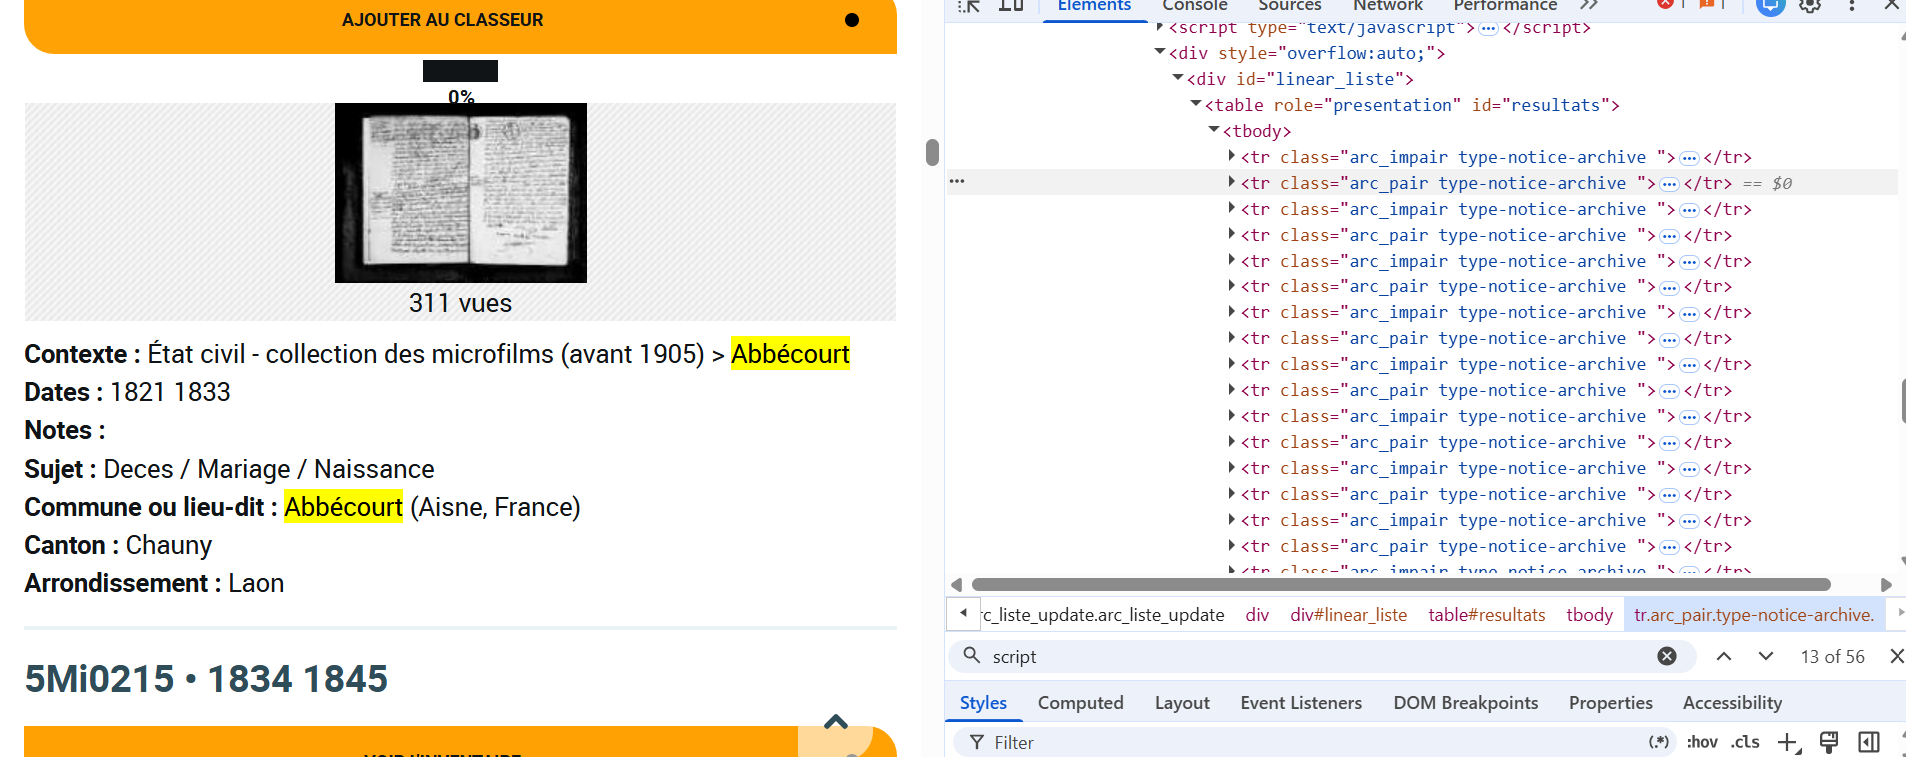

Après avoir récupéré la page réelle (`debug_page_real.html`), j'ai constaté que les résultats n'étaient pas présentés sous la forme d'un tableau classique avec une colonne par information.

Chaque registre était contenu dans une seule cellule `<td>`, dans laquelle toutes les informations (cote, années, type d'acte, collection et liens) étaient regroupées sous forme de texte.

Cette structure ne permettait pas d'extraire directement les champs souhaités avec BeautifulSoup.


**Solution :** parseur regex ciblé avec des ancres textuelles fiables :
j'ai utilisé des expressions régulières (regex) en m'appuyant sur des repères textuels présents dans chaque cellule, tels que **« Dates : »**, **« Sujet : »** ou **« Contexte : »**, afin d'isoler automatiquement chaque information.

=> Pour récupérer le lien vers l'image du registre, j'ai sélectionné le lien contenant le motif `daogrp/0/layout:linear`, qui correspond au visualiseur de l'image.


## Étape 6 — Obstacle n°3 : Gestion de la pagination

Après avoir extrait les premiers résultats, j'ai vérifié que tous les registres étaient bien récupérés.

En analysant les liens de pagination présents dans le HTML, j'ai constaté que le site affichait plusieurs pages de résultats.

En parcourant les pages une par une, j'ai observé qu'après la dernière page réelle, le serveur ne renvoyait ni une erreur ni une page vide. Il recommençait simplement à renvoyer les résultats de la première page, ce qui pouvait entraîner la collecte de nombreux doublons.

### Solution mise en place

Pour éviter ce problème, j'ai utilisé deux approches :

1. **Extraction directe** avec une URL utilisant `limit:50`, ce qui permet de récupérer les **41 registres** en une seule requête puisque le nombre total de résultats est inférieur à 50.

2. **Détection des doublons** lors de la pagination en calculant une empreinte (**MD5**) du contenu HTML de chaque page. Si une page déjà rencontrée est détectée, le script arrête automatiquement la pagination afin d'éviter une boucle infinie.

### Vérification

J'ai comparé les résultats obtenus avec plusieurs tailles de pagination (`limit:50`, `limit:20`, `limit:10` et `limit:5`). Dans tous les cas, le nombre total de registres extraits était identique (**41**), ce qui confirme que l'extraction est complète.

---

## Résultats obtenus

| Indicateur | Résultat |
|------------|-----------|
| Registres extraits | **41** |
| Liens vers les images | **41/41 valides** |
| Champs obligatoires | **Tous renseignés** |
| Période couverte | **1669 à 1949** |
| Durée de l'extraction | **Environ 45 minutes** |

### Fichiers livrés

- `abbecourt_aisne_COMPLET.csv`
- `abbecourt_aisne_COMPLET.xlsx`
- `extract_all_pages.py`